In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [5]:
ruta = Path('/content/base_economíacolombiana_codificada (1).xlsx')

### 2. Leer base

In [6]:
df = pd.read_excel(ruta)
print("Dimensiones iniciales:", df.shape)

Dimensiones iniciales: (6745, 157)


In [7]:
print("\nPrimeras columnas:")
print(df.columns.to_list())


Primeras columnas:
['municipio', 'an', 'sexo', 'edad', 'nivels', 'percepción', 'orgullo', 'satisfacción', 'futuro', 'economía', 'plaboral', 'ftrabajo', 'pobre', 'spobre', 'npobre', 'comida', 'infancia', 'secundaria', 'superior', 'pública', 'privada', 'salud', 'ssalud', 'mseguridad', 'bseguridad', 'prseguridad', 'delito', 'denuncia', 'sanción', 'barrio', 'parques', 'vías', 'vivienda', 'gas', 'electricidad', 'agua', 'aseo', 'internet', 'celular', 'espacio', 'transporte', 'bus', 'taxi', 'vehículo', 'moto', '¿Qué nivel de satisfacción tiene con el transporte en Mototaxi?', 'a_pie', 'bicicleta', 'trans_otro', 'aguas', 'aire', 'ruido', 'basura', 'escombros', 'contaminación', 'árboles', 'cultural', 'deporte', 'juntas', 'club', 'redes', 'asociaciones', 'defensa', 'universitaria', 'grupos', 'religión', 'voluntariado', 'movimientos', 'derechos', 'política', 'sindicatos', 'colectivos', 'otrogrupo', 'Si contestó otro ¿cuál?...79', 'discapacidad', 'vecinos', 'ninos', 'mayores', 'etnia', 'mujeres',

In [8]:
# ============================================================
# BLOQUE 1. CONFIGURACIÓN GENERAL DEL ANÁLISIS
# Cultura ciudadana — primeras 7 variables
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

try:
    from scipy.stats import chi2_contingency
    scipy_disponible = True
except ImportError:
    scipy_disponible = False
    print("Advertencia: scipy no está instalado. No se calcularán pruebas chi-cuadrado.")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid", font_scale=1.05)

# Carpetas de salida
salida = Path("salidas_cultura_ciudadana")
carpeta_tablas = salida / "tablas"
carpeta_graficos = salida / "graficos"

carpeta_tablas.mkdir(parents=True, exist_ok=True)
carpeta_graficos.mkdir(parents=True, exist_ok=True)

print("Carpetas creadas correctamente.")




Carpetas creadas correctamente.


In [9]:
# ============================================================
# BLOQUE 2. VARIABLES DEL ANÁLISIS
# ============================================================

# Primeras 7 variables de Cultura Ciudadana
vars_cultura = [
    "honestidad",
    "convivencia",
    "bienes",
    "tránsito",
    "ambiental",
    "migrantes",
    "pensamiento"
]

# Variables transversales exigidas por la guía
vars_transversales = [
    "municipio",
    "an",
    "sexo",
    "edad",
    "nivels",
    "nedu"
]

# Diccionario conceptual para interpretación posterior
diccionario_conceptual = {
    "honestidad": "Legalidad y honestidad frente a la conexión a servicios públicos.",
    "convivencia": "Cumplimiento de normas básicas de convivencia.",
    "bienes": "Cuidado y respeto por espacios y bienes públicos.",
    "tránsito": "Respeto por normas básicas de tránsito.",
    "ambiental": "Respeto por normas ambientales.",
    "migrantes": "Comportamiento ciudadano frente a migrantes o refugiados.",
    "pensamiento": "Tolerancia frente a personas que piensan políticamente diferente."
}

tabla_conceptual = pd.DataFrame({
    "variable": list(diccionario_conceptual.keys()),
    "interpretacion_conceptual": list(diccionario_conceptual.values())
})

display(tabla_conceptual)



,variable,interpretacion_conceptual
0,honestidad,Legalidad y honestidad frente a la conexión a ...
1,convivencia,Cumplimiento de normas básicas de convivencia.
2,bienes,Cuidado y respeto por espacios y bienes públicos.
3,tránsito,Respeto por normas básicas de tránsito.
4,ambiental,Respeto por normas ambientales.
5,migrantes,Comportamiento ciudadano frente a migrantes o ...
6,pensamiento,Tolerancia frente a personas que piensan polít...


In [10]:
# ============================================================
# BLOQUE 3. VALIDACIÓN DE COLUMNAS REALES EN LA BASE
# ============================================================

columnas_necesarias = vars_transversales + vars_cultura

columnas_existentes = df.columns.tolist()
columnas_faltantes = [col for col in columnas_necesarias if col not in columnas_existentes]

print("Columnas necesarias:")
print(columnas_necesarias)

if len(columnas_faltantes) == 0:
    print("\nTodas las columnas necesarias están presentes en la base.")
else:
    print("\nATENCIÓN. Estas columnas no aparecen exactamente con ese nombre:")
    print(columnas_faltantes)
    print("\nRevisa tildes, espacios o diferencias en los encabezados reales.")




Columnas necesarias:
['municipio', 'an', 'sexo', 'edad', 'nivels', 'nedu', 'honestidad', 'convivencia', 'bienes', 'tránsito', 'ambiental', 'migrantes', 'pensamiento']

Todas las columnas necesarias están presentes en la base.


In [11]:
# ============================================================
# BLOQUE 4. CREACIÓN DE BASE DE TRABAJO
# ============================================================

df_cultura = df[columnas_necesarias].copy()

print("Dimensiones de la base original:", df.shape)
print("Dimensiones de la base de cultura ciudadana:", df_cultura.shape)

display(df_cultura.head())




Dimensiones de la base original: (6745, 157)
Dimensiones de la base de cultura ciudadana: (6745, 13)


,municipio,an,sexo,edad,nivels,nedu,honestidad,convivencia,bienes,tránsito,ambiental,migrantes,pensamiento
0,1,2021,0,31,1,NaN,1,1,1,0,1,NaN,NaN
1,1,2021,1,21,0,NaN,0,0,0,0,0,NaN,NaN
2,1,2021,1,27,1,NaN,0,1,0,0,0,NaN,NaN
3,1,2021,1,19,1,NaN,0,0,0,0,0,NaN,NaN
4,1,2021,1,22,0,NaN,1,1,0,0,1,NaN,NaN


In [12]:
# ============================================================
# BLOQUE 5. ETIQUETADO DE VARIABLES TRANSVERSALES
# ============================================================

map_municipio = {
    0: "Pitalito",
    1: "Garzón",
    2: "Neiva"
}

map_sexo = {
    0: "Masculino",
    1: "Femenino"
}

map_nivels = {
    0: "Bajo",
    1: "Medio",
    2: "Alto"
}

map_nedu = {
    1: "Ninguno",
    2: "Hasta primaria",
    3: "Bachillerato / Técnico / Tecnológico",
    4: "Superior",
    5: "Pregrado",
    6: "Posgrado"
}

map_binaria = {
    0: "No",
    1: "Sí"
}

df_cultura["municipio_etq"] = df_cultura["municipio"].map(map_municipio)
df_cultura["sexo_etq"] = df_cultura["sexo"].map(map_sexo)
df_cultura["nivels_etq"] = df_cultura["nivels"].map(map_nivels)
df_cultura["nedu_etq"] = df_cultura["nedu"].map(map_nedu)

for var in vars_cultura:
    df_cultura[f"{var}_etq"] = df_cultura[var].map(map_binaria)

print("Etiquetado realizado correctamente.")

display(df_cultura.head())




Etiquetado realizado correctamente.


,municipio,an,sexo,edad,nivels,nedu,honestidad,convivencia,bienes,tránsito,ambiental,migrantes,pensamiento,municipio_etq,sexo_etq,nivels_etq,nedu_etq,honestidad_etq,convivencia_etq,bienes_etq,tránsito_etq,ambiental_etq,migrantes_etq,pensamiento_etq
0,1,2021,0,31,1,NaN,1,1,1,0,1,NaN,NaN,Garzón,Masculino,Medio,NaN,Sí,Sí,Sí,No,Sí,NaN,NaN
1,1,2021,1,21,0,NaN,0,0,0,0,0,NaN,NaN,Garzón,Femenino,Bajo,NaN,No,No,No,No,No,NaN,NaN
2,1,2021,1,27,1,NaN,0,1,0,0,0,NaN,NaN,Garzón,Femenino,Medio,NaN,No,Sí,No,No,No,NaN,NaN
3,1,2021,1,19,1,NaN,0,0,0,0,0,NaN,NaN,Garzón,Femenino,Medio,NaN,No,No,No,No,No,NaN,NaN
4,1,2021,1,22,0,NaN,1,1,0,0,1,NaN,NaN,Garzón,Femenino,Bajo,NaN,Sí,Sí,No,No,Sí,NaN,NaN


In [13]:
# ============================================================
# BLOQUE 6. VALIDACIÓN DEL PANEL DESBALANCEADO
# ============================================================

panel_municipio_anio = (
    df_cultura
    .groupby(["municipio_etq", "an"], dropna=False)
    .size()
    .reset_index(name="n_observaciones")
    .sort_values(["municipio_etq", "an"])
)

print("Distribución de observaciones por municipio y año:")
display(panel_municipio_anio)

panel_municipio_anio.to_excel(
    carpeta_tablas / "01_validacion_panel_municipio_anio.xlsx",
    index=False
)




Distribución de observaciones por municipio y año:


,municipio_etq,an,n_observaciones
0,Garzón,2021,431
1,Garzón,2022,1219
2,Garzón,2023,1287
3,Garzón,2024,412
4,Garzón,2025,441
5,Neiva,2024,1160
6,Neiva,2025,1160
7,Pitalito,2025,635


In [14]:
# ============================================================
# BLOQUE 7. VALIDACIÓN DE VALORES EN VARIABLES DE CULTURA
# ============================================================

validacion_valores = []

for var in vars_cultura:
    conteo = df_cultura[var].value_counts(dropna=False).reset_index()
    conteo.columns = ["valor", "frecuencia"]
    conteo["variable"] = var
    conteo["interpretacion"] = conteo["valor"].map({
        0: "No",
        1: "Sí",
        np.nan: "NA / Sin dato"
    })
    validacion_valores.append(conteo)

validacion_valores = pd.concat(validacion_valores, ignore_index=True)

print("Validación de valores 0/1/NA en variables de cultura ciudadana:")
display(validacion_valores)

validacion_valores.to_excel(
    carpeta_tablas / "02_validacion_valores_variables_cultura.xlsx",
    index=False
)




Validación de valores 0/1/NA en variables de cultura ciudadana:


,valor,frecuencia,variable,interpretacion
0,0.0,3821,honestidad,No
1,1.0,2924,honestidad,Sí
2,0.0,3842,convivencia,No
3,1.0,2903,convivencia,Sí
4,0.0,4196,bienes,No
5,1.0,2549,bienes,Sí
6,0.0,4508,tránsito,No
7,1.0,2237,tránsito,Sí
8,0.0,4727,ambiental,No
9,1.0,2018,ambiental,Sí


In [15]:
# ============================================================
# BLOQUE 8. REVISIÓN DE NA Y DENOMINADORES
# ============================================================

resumen_na = []

for var in vars_cultura:
    total = len(df_cultura)
    n_validos = df_cultura[var].notna().sum()
    n_na = df_cultura[var].isna().sum()

    resumen_na.append({
        "variable": var,
        "interpretacion_conceptual": diccionario_conceptual[var],
        "n_total_base": total,
        "n_validos_denominador": n_validos,
        "n_na": n_na,
        "porcentaje_na": round((n_na / total) * 100, 2)
    })

resumen_na = pd.DataFrame(resumen_na)

print("Resumen de NA y denominadores:")
display(resumen_na)

resumen_na.to_excel(
    carpeta_tablas / "03_resumen_na_denominadores.xlsx",
    index=False
)




Resumen de NA y denominadores:


,variable,interpretacion_conceptual,n_total_base,n_validos_denominador,n_na,porcentaje_na
0,honestidad,Legalidad y honestidad frente a la conexión a ...,6745,6745,0,0.00
1,convivencia,Cumplimiento de normas básicas de convivencia.,6745,6745,0,0.00
2,bienes,Cuidado y respeto por espacios y bienes públicos.,6745,6745,0,0.00
3,tránsito,Respeto por normas básicas de tránsito.,6745,6745,0,0.00
4,ambiental,Respeto por normas ambientales.,6745,6745,0,0.00
5,migrantes,Comportamiento ciudadano frente a migrantes o ...,6745,5095,1650,24.46
6,pensamiento,Tolerancia frente a personas que piensan polít...,6745,5095,1650,24.46


In [16]:
# ============================================================
# BLOQUE 9. DESCRIPTIVOS GENERALES
# Frecuencias y porcentajes de Sí/No por variable
# ============================================================

descriptivos_generales = []

for var in vars_cultura:
    temp = (
        df_cultura[var]
        .map(map_binaria)
        .value_counts(dropna=False)
        .reset_index()
    )
    temp.columns = ["respuesta", "frecuencia"]
    temp["variable"] = var
    temp["interpretacion_conceptual"] = diccionario_conceptual[var]

    denominador = df_cultura[var].notna().sum()
    temp["denominador_valido"] = denominador
    temp["porcentaje_sobre_validos"] = np.where(
        temp["respuesta"].isin(["No", "Sí"]),
        round((temp["frecuencia"] / denominador) * 100, 2),
        np.nan
    )

    descriptivos_generales.append(temp)

descriptivos_generales = pd.concat(descriptivos_generales, ignore_index=True)

print("Descriptivos generales de cultura ciudadana:")
display(descriptivos_generales)

descriptivos_generales.to_excel(
    carpeta_tablas / "04_descriptivos_generales_si_no.xlsx",
    index=False
)




Descriptivos generales de cultura ciudadana:


,respuesta,frecuencia,variable,interpretacion_conceptual,denominador_valido,porcentaje_sobre_validos
0,No,3821,honestidad,Legalidad y honestidad frente a la conexión a ...,6745,56.65
1,Sí,2924,honestidad,Legalidad y honestidad frente a la conexión a ...,6745,43.35
2,No,3842,convivencia,Cumplimiento de normas básicas de convivencia.,6745,56.96
3,Sí,2903,convivencia,Cumplimiento de normas básicas de convivencia.,6745,43.04
4,No,4196,bienes,Cuidado y respeto por espacios y bienes públicos.,6745,62.21
5,Sí,2549,bienes,Cuidado y respeto por espacios y bienes públicos.,6745,37.79
6,No,4508,tránsito,Respeto por normas básicas de tránsito.,6745,66.83
7,Sí,2237,tránsito,Respeto por normas básicas de tránsito.,6745,33.17
8,No,4727,ambiental,Respeto por normas ambientales.,6745,70.08
9,Sí,2018,ambiental,Respeto por normas ambientales.,6745,29.92


In [17]:
# ============================================================
# BLOQUE 10. RANKING GENERAL DE RESPUESTAS 'SÍ'
# ============================================================

ranking_si = []

for var in vars_cultura:
    serie = df_cultura[var].dropna()
    n_validos = len(serie)
    n_si = (serie == 1).sum()
    porcentaje_si = (n_si / n_validos) * 100 if n_validos > 0 else np.nan

    ranking_si.append({
        "variable": var,
        "interpretacion_conceptual": diccionario_conceptual[var],
        "n_validos": n_validos,
        "n_si": n_si,
        "porcentaje_si": round(porcentaje_si, 2)
    })

ranking_si = pd.DataFrame(ranking_si).sort_values("porcentaje_si", ascending=False)

print("Ranking general de cumplimiento/percepción positiva:")
display(ranking_si)

ranking_si.to_excel(
    carpeta_tablas / "05_ranking_general_porcentaje_si.xlsx",
    index=False
)




Ranking general de cumplimiento/percepción positiva:


,variable,interpretacion_conceptual,n_validos,n_si,porcentaje_si
0,honestidad,Legalidad y honestidad frente a la conexión a ...,6745,2924,43.35
1,convivencia,Cumplimiento de normas básicas de convivencia.,6745,2903,43.04
2,bienes,Cuidado y respeto por espacios y bienes públicos.,6745,2549,37.79
6,pensamiento,Tolerancia frente a personas que piensan polít...,5095,1767,34.68
3,tránsito,Respeto por normas básicas de tránsito.,6745,2237,33.17
5,migrantes,Comportamiento ciudadano frente a migrantes o ...,5095,1592,31.25
4,ambiental,Respeto por normas ambientales.,6745,2018,29.92


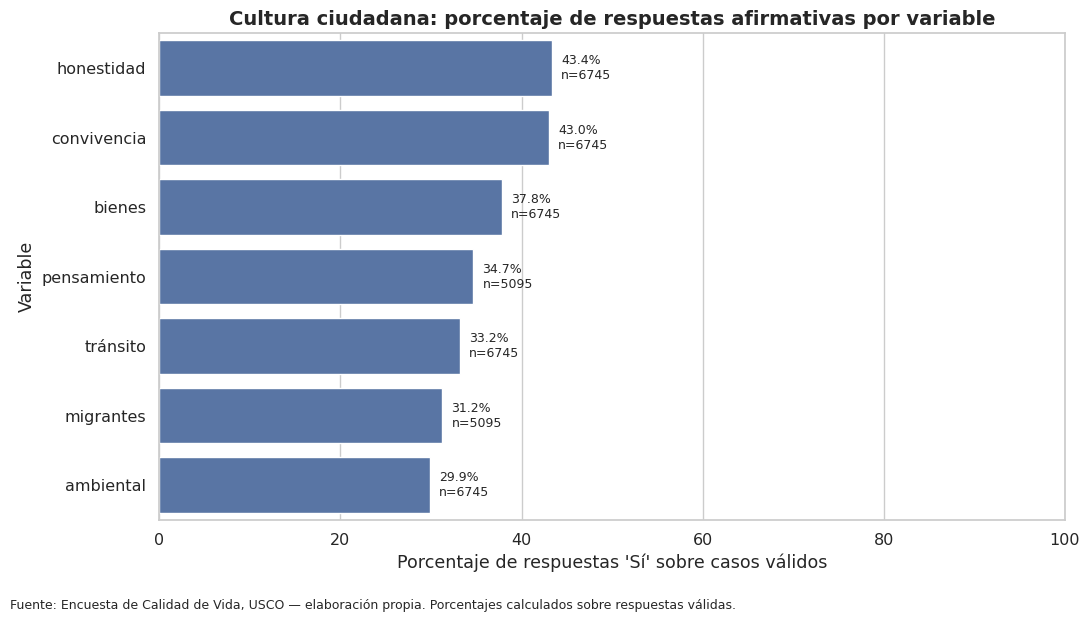

In [18]:
# ============================================================
# BLOQUE 11. GRÁFICO 1
# Ranking general de cultura ciudadana
# ============================================================

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=ranking_si,
    y="variable",
    x="porcentaje_si",
    orient="h"
)

plt.title("Cultura ciudadana: porcentaje de respuestas afirmativas por variable", fontsize=14, weight="bold")
plt.xlabel("Porcentaje de respuestas 'Sí' sobre casos válidos")
plt.ylabel("Variable")
plt.xlim(0, 100)

for i, row in ranking_si.reset_index(drop=True).iterrows():
    ax.text(
        row["porcentaje_si"] + 1,
        i,
        f'{row["porcentaje_si"]:.1f}%\nn={row["n_validos"]}',
        va="center",
        fontsize=9
    )

plt.figtext(
    0.01, -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia. Porcentajes calculados sobre respuestas válidas.",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig(carpeta_graficos / "01_ranking_general_cultura_ciudadana.png", dpi=300, bbox_inches="tight")
plt.show()




In [19]:
# ============================================================
# BLOQUE 12. COMPARACIÓN ENTRE MUNICIPIOS SOLO PARA 2025
# Regla del profesor: los tres municipios solo son comparables en 2025
# ============================================================

df_2025 = df_cultura[df_cultura["an"] == 2025].copy()

municipio_2025 = []

for var in vars_cultura:
    temp = (
        df_2025
        .groupby("municipio_etq")[var]
        .agg(
            n_validos=lambda x: x.notna().sum(),
            n_si=lambda x: (x == 1).sum()
        )
        .reset_index()
    )
    temp["variable"] = var
    temp["porcentaje_si"] = np.where(
        temp["n_validos"] > 0,
        round((temp["n_si"] / temp["n_validos"]) * 100, 2),
        np.nan
    )
    municipio_2025.append(temp)

municipio_2025 = pd.concat(municipio_2025, ignore_index=True)

print("Comparación válida entre municipios, solo año 2025:")
display(municipio_2025)

municipio_2025.to_excel(
    carpeta_tablas / "06_comparacion_municipios_2025.xlsx",
    index=False
)




Comparación válida entre municipios, solo año 2025:


,municipio_etq,n_validos,n_si,variable,porcentaje_si
0,Garzón,441,228,honestidad,51.70
1,Neiva,1160,453,honestidad,39.05
2,Pitalito,635,304,honestidad,47.87
3,Garzón,441,225,convivencia,51.02
4,Neiva,1160,406,convivencia,35.00
5,Pitalito,635,284,convivencia,44.72
6,Garzón,441,152,bienes,34.47
7,Neiva,1160,442,bienes,38.10
8,Pitalito,635,264,bienes,41.57
9,Garzón,441,99,tránsito,22.45


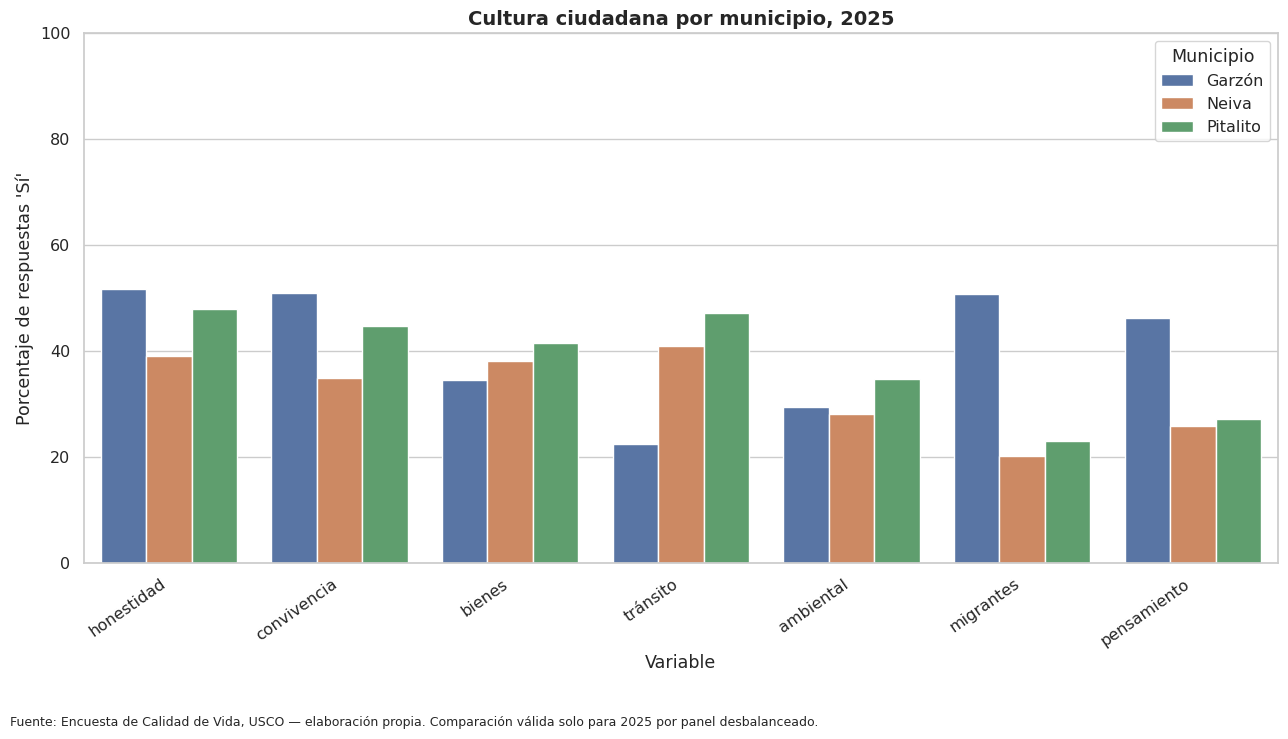

In [20]:
# ============================================================
# BLOQUE 13. GRÁFICO 2
# Comparación municipal 2025
# ============================================================

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=municipio_2025,
    x="variable",
    y="porcentaje_si",
    hue="municipio_etq"
)

plt.title("Cultura ciudadana por municipio, 2025", fontsize=14, weight="bold")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de respuestas 'Sí'")
plt.ylim(0, 100)
plt.xticks(rotation=35, ha="right")
plt.legend(title="Municipio")

plt.figtext(
    0.01, -0.05,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia. Comparación válida solo para 2025 por panel desbalanceado.",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig(carpeta_graficos / "02_comparacion_municipios_2025.png", dpi=300, bbox_inches="tight")
plt.show()




In [21]:
# ============================================================
# BLOQUE 14. EVOLUCIÓN TEMPORAL DE GARZÓN 2021-2025
# Regla del profesor: Garzón es el único municipio con serie completa
# ============================================================

df_garzon = df_cultura[df_cultura["municipio_etq"] == "Garzón"].copy()

garzon_tiempo = []

for var in vars_cultura:
    temp = (
        df_garzon
        .groupby("an")[var]
        .agg(
            n_validos=lambda x: x.notna().sum(),
            n_si=lambda x: (x == 1).sum()
        )
        .reset_index()
    )
    temp["variable"] = var
    temp["porcentaje_si"] = np.where(
        temp["n_validos"] > 0,
        round((temp["n_si"] / temp["n_validos"]) * 100, 2),
        np.nan
    )
    garzon_tiempo.append(temp)

garzon_tiempo = pd.concat(garzon_tiempo, ignore_index=True)

print("Evolución válida para Garzón 2021-2025:")
display(garzon_tiempo)

garzon_tiempo.to_excel(
    carpeta_tablas / "07_evolucion_garzon_2021_2025.xlsx",
    index=False
)




Evolución válida para Garzón 2021-2025:


,an,n_validos,n_si,variable,porcentaje_si
0,2021,431,167,honestidad,38.75
1,2022,1219,529,honestidad,43.40
2,2023,1287,583,honestidad,45.30
3,2024,412,207,honestidad,50.24
4,2025,441,228,honestidad,51.70
5,2021,431,204,convivencia,47.33
6,2022,1219,541,convivencia,44.38
7,2023,1287,620,convivencia,48.17
8,2024,412,217,convivencia,52.67
9,2025,441,225,convivencia,51.02


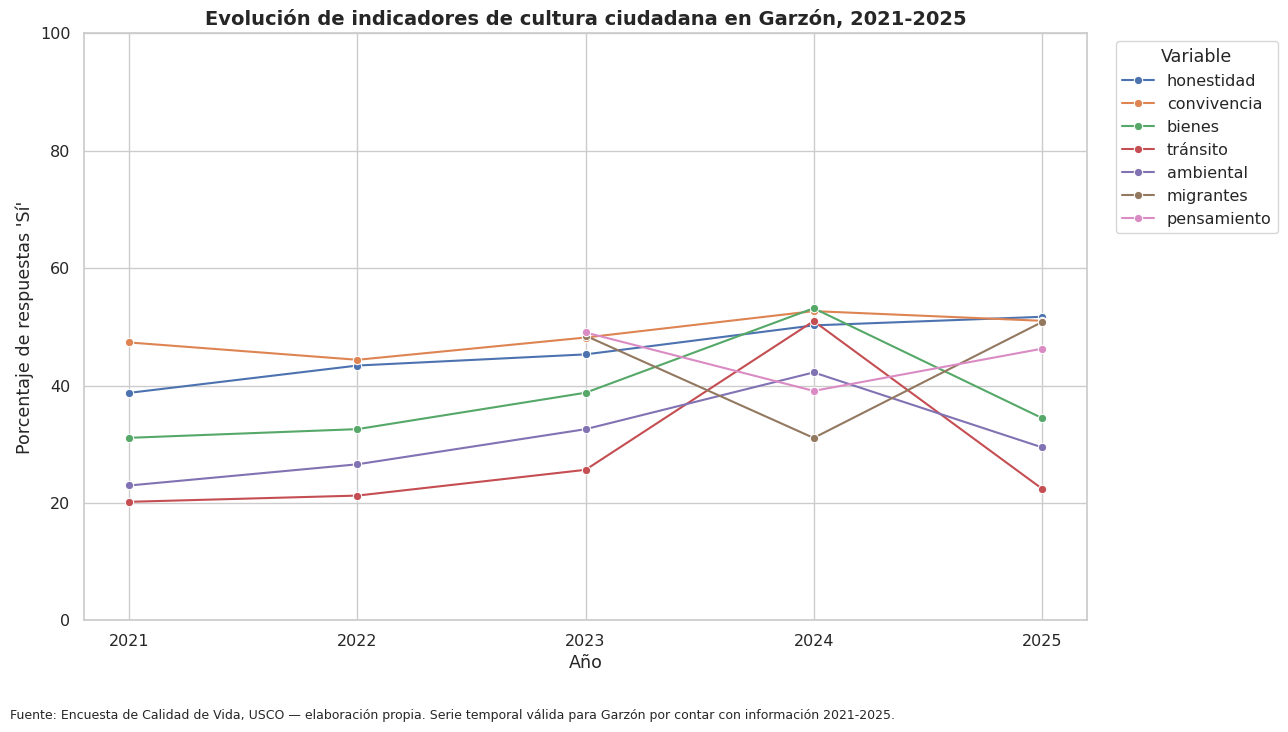

In [22]:
# ============================================================
# BLOQUE 15. GRÁFICO 3
# Evolución de Garzón
# ============================================================

plt.figure(figsize=(13, 7))

ax = sns.lineplot(
    data=garzon_tiempo,
    x="an",
    y="porcentaje_si",
    hue="variable",
    marker="o"
)

plt.title("Evolución de indicadores de cultura ciudadana en Garzón, 2021-2025", fontsize=14, weight="bold")
plt.xlabel("Año")
plt.ylabel("Porcentaje de respuestas 'Sí'")
plt.ylim(0, 100)
plt.xticks(sorted(df_garzon["an"].dropna().unique()))
plt.legend(title="Variable", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.figtext(
    0.01, -0.04,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia. Serie temporal válida para Garzón por contar con información 2021-2025.",
    ha="left",
    fontsize=9
)

plt.tight_layout()
plt.savefig(carpeta_graficos / "03_evolucion_garzon_2021_2025.png", dpi=300, bbox_inches="tight")
plt.show()




In [23]:
# ============================================================
# BLOQUE 16. COMPARACIÓN NEIVA 2024-2025
# Regla del profesor: Neiva solo permite comparar 2024 frente a 2025
# ============================================================

df_neiva = df_cultura[df_cultura["municipio_etq"] == "Neiva"].copy()

neiva_tiempo = []

for var in vars_cultura:
    temp = (
        df_neiva
        .groupby("an")[var]
        .agg(
            n_validos=lambda x: x.notna().sum(),
            n_si=lambda x: (x == 1).sum()
        )
        .reset_index()
    )
    temp["variable"] = var
    temp["porcentaje_si"] = np.where(
        temp["n_validos"] > 0,
        round((temp["n_si"] / temp["n_validos"]) * 100, 2),
        np.nan
    )
    neiva_tiempo.append(temp)

neiva_tiempo = pd.concat(neiva_tiempo, ignore_index=True)

print("Comparación válida para Neiva 2024-2025:")
display(neiva_tiempo)

neiva_tiempo.to_excel(
    carpeta_tablas / "08_comparacion_neiva_2024_2025.xlsx",
    index=False
)




Comparación válida para Neiva 2024-2025:


,an,n_validos,n_si,variable,porcentaje_si
0,2024,1160,453,honestidad,39.05
1,2025,1160,453,honestidad,39.05
2,2024,1160,406,convivencia,35.00
3,2025,1160,406,convivencia,35.00
4,2024,1160,442,bienes,38.10
5,2025,1160,442,bienes,38.10
6,2024,1160,476,tránsito,41.03
7,2025,1160,476,tránsito,41.03
8,2024,1160,326,ambiental,28.10
9,2025,1160,326,ambiental,28.10


In [24]:
# ============================================================
# BLOQUE 17. CRUCE POR SEXO
# ============================================================

cruce_sexo = []

for var in vars_cultura:
    temp = (
        df_cultura
        .groupby("sexo_etq")[var]
        .agg(
            n_validos=lambda x: x.notna().sum(),
            n_si=lambda x: (x == 1).sum()
        )
        .reset_index()
    )
    temp["variable"] = var
    temp["porcentaje_si"] = np.where(
        temp["n_validos"] > 0,
        round((temp["n_si"] / temp["n_validos"]) * 100, 2),
        np.nan
    )
    cruce_sexo.append(temp)

cruce_sexo = pd.concat(cruce_sexo, ignore_index=True)

print("Cruce de variables de cultura ciudadana por sexo:")
display(cruce_sexo)

cruce_sexo.to_excel(
    carpeta_tablas / "09_cruce_por_sexo.xlsx",
    index=False
)




Cruce de variables de cultura ciudadana por sexo:


,sexo_etq,n_validos,n_si,variable,porcentaje_si
0,Femenino,3706,1573,honestidad,42.44
1,Masculino,3039,1351,honestidad,44.46
2,Femenino,3706,1554,convivencia,41.93
3,Masculino,3039,1349,convivencia,44.39
4,Femenino,3706,1382,bienes,37.29
5,Masculino,3039,1167,bienes,38.40
6,Femenino,3706,1163,tránsito,31.38
7,Masculino,3039,1074,tránsito,35.34
8,Femenino,3706,1029,ambiental,27.77
9,Masculino,3039,989,ambiental,32.54


In [25]:
# ============================================================
# BLOQUE 18. CRUCE POR NIVEL SOCIOECONÓMICO
# ============================================================

cruce_nivels = []

for var in vars_cultura:
    temp = (
        df_cultura
        .groupby("nivels_etq")[var]
        .agg(
            n_validos=lambda x: x.notna().sum(),
            n_si=lambda x: (x == 1).sum()
        )
        .reset_index()
    )
    temp["variable"] = var
    temp["porcentaje_si"] = np.where(
        temp["n_validos"] > 0,
        round((temp["n_si"] / temp["n_validos"]) * 100, 2),
        np.nan
    )
    cruce_nivels.append(temp)

cruce_nivels = pd.concat(cruce_nivels, ignore_index=True)

print("Cruce de variables de cultura ciudadana por nivel socioeconómico:")
display(cruce_nivels)

cruce_nivels.to_excel(
    carpeta_tablas / "10_cruce_por_nivel_socioeconomico.xlsx",
    index=False
)




Cruce de variables de cultura ciudadana por nivel socioeconómico:


,nivels_etq,n_validos,n_si,variable,porcentaje_si
0,Alto,174,77,honestidad,44.25
1,Bajo,2562,1022,honestidad,39.89
2,Medio,4009,1825,honestidad,45.52
3,Alto,174,86,convivencia,49.43
4,Bajo,2562,1004,convivencia,39.19
5,Medio,4009,1813,convivencia,45.22
6,Alto,174,93,bienes,53.45
7,Bajo,2562,872,bienes,34.04
8,Medio,4009,1584,bienes,39.51
9,Alto,174,69,tránsito,39.66


In [26]:
# ============================================================
# BLOQUE 19. EDAD AGRUPADA
# ============================================================

bins_edad = [17, 25, 35, 45, 60, 100]
labels_edad = ["18-25", "26-35", "36-45", "46-60", "61 o más"]

df_cultura["grupo_edad"] = pd.cut(
    df_cultura["edad"],
    bins=bins_edad,
    labels=labels_edad
)

cruce_edad = []

for var in vars_cultura:
    temp = (
        df_cultura
        .groupby("grupo_edad", observed=False)[var]
        .agg(
            n_validos=lambda x: x.notna().sum(),
            n_si=lambda x: (x == 1).sum()
        )
        .reset_index()
    )
    temp["variable"] = var
    temp["porcentaje_si"] = np.where(
        temp["n_validos"] > 0,
        round((temp["n_si"] / temp["n_validos"]) * 100, 2),
        np.nan
    )
    cruce_edad.append(temp)

cruce_edad = pd.concat(cruce_edad, ignore_index=True)

print("Cruce de variables de cultura ciudadana por grupo de edad:")
display(cruce_edad)

cruce_edad.to_excel(
    carpeta_tablas / "11_cruce_por_grupo_edad.xlsx",
    index=False
)




Cruce de variables de cultura ciudadana por grupo de edad:


,grupo_edad,n_validos,n_si,variable,porcentaje_si
0,18-25,3621,1592,honestidad,43.97
1,26-35,1395,556,honestidad,39.86
2,36-45,825,369,honestidad,44.73
3,46-60,673,298,honestidad,44.28
4,61 o más,231,109,honestidad,47.19
5,18-25,3621,1583,convivencia,43.72
6,26-35,1395,549,convivencia,39.35
7,36-45,825,376,convivencia,45.58
8,46-60,673,293,convivencia,43.54
9,61 o más,231,102,convivencia,44.16


In [27]:
# ============================================================
# BLOQUE 20. PRUEBAS CHI-CUADRADO
# Asociación, no causalidad
# ============================================================

resultados_chi2 = []

if scipy_disponible:
    cruces_inferencia = {
        "municipio_2025": ("municipio_etq", df_2025),
        "sexo_base_total": ("sexo_etq", df_cultura),
        "nivel_socioeconomico_base_total": ("nivels_etq", df_cultura)
    }

    for nombre_cruce, (grupo, base_temp) in cruces_inferencia.items():
        for var in vars_cultura:
            tabla = pd.crosstab(base_temp[grupo], base_temp[var])

            if tabla.shape[0] >= 2 and tabla.shape[1] >= 2:
                chi2, p, dof, expected = chi2_contingency(tabla)

                resultados_chi2.append({
                    "cruce": nombre_cruce,
                    "variable": var,
                    "grupo": grupo,
                    "chi2": round(chi2, 4),
                    "p_valor": round(p, 4),
                    "grados_libertad": dof,
                    "n_observaciones_validas": int(tabla.to_numpy().sum()),
                    "interpretacion": (
                        "Hay evidencia estadística de asociación al 5%, sin implicar causalidad."
                        if p < 0.05 else
                        "No se observa evidencia estadística suficiente de asociación al 5%."
                    )
                })

    resultados_chi2 = pd.DataFrame(resultados_chi2)

    print("Resultados de pruebas chi-cuadrado:")
    display(resultados_chi2)

    resultados_chi2.to_excel(
        carpeta_tablas / "12_pruebas_chi_cuadrado.xlsx",
        index=False
    )

else:
    print("No se ejecutaron pruebas chi-cuadrado porque scipy no está disponible.")




Resultados de pruebas chi-cuadrado:


,cruce,variable,grupo,chi2,p_valor,grados_libertad,n_observaciones_validas,interpretacion
0,municipio_2025,honestidad,municipio_etq,25.9994,0.0000,2,2236,"Hay evidencia estadística de asociación al 5%,..."
1,municipio_2025,convivencia,municipio_etq,39.2271,0.0000,2,2236,"Hay evidencia estadística de asociación al 5%,..."
2,municipio_2025,bienes,municipio_etq,5.6334,0.0598,2,2236,No se observa evidencia estadística suficiente...
3,municipio_2025,tránsito,municipio_etq,70.8369,0.0000,2,2236,"Hay evidencia estadística de asociación al 5%,..."
4,municipio_2025,ambiental,municipio_etq,8.4751,0.0144,2,2236,"Hay evidencia estadística de asociación al 5%,..."
5,municipio_2025,migrantes,municipio_etq,158.3767,0.0000,2,2236,"Hay evidencia estadística de asociación al 5%,..."
6,municipio_2025,pensamiento,municipio_etq,67.3101,0.0000,2,2236,"Hay evidencia estadística de asociación al 5%,..."
7,sexo_base_total,honestidad,sexo_etq,2.6677,0.1024,1,6745,No se observa evidencia estadística suficiente...
8,sexo_base_total,convivencia,sexo_etq,4.0141,0.0451,1,6745,"Hay evidencia estadística de asociación al 5%,..."
9,sexo_base_total,bienes,sexo_etq,0.8284,0.3627,1,6745,No se observa evidencia estadística suficiente...


In [28]:
# ============================================================
# BLOQUE 21. NOTAS AUTOMÁTICAS PARA STORYTELLING
# Estas frases son insumos iniciales, no conclusiones definitivas.
# ============================================================

notas_storytelling = []

for _, row in ranking_si.iterrows():
    notas_storytelling.append({
        "variable": row["variable"],
        "dato_ancla": f"El {row['porcentaje_si']:.1f}% de las respuestas válidas fue 'Sí' en {row['variable']} (n = {int(row['n_validos'])}).",
        "lectura_prudente": (
            f"Este resultado puede leerse como una señal de percepción ciudadana sobre "
            f"{row['interpretacion_conceptual'].lower()} No debe interpretarse como medición objetiva "
            f"del comportamiento real, sino como percepción declarada por las personas encuestadas."
        )
    })

notas_storytelling = pd.DataFrame(notas_storytelling)

print("Notas iniciales para narrativa:")
display(notas_storytelling)

notas_storytelling.to_excel(
    carpeta_tablas / "13_notas_storytelling_inicial.xlsx",
    index=False
)




Notas iniciales para narrativa:


,variable,dato_ancla,lectura_prudente
0,honestidad,El 43.4% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...
1,convivencia,El 43.0% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...
2,bienes,El 37.8% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...
3,pensamiento,El 34.7% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...
4,tránsito,El 33.2% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...
5,migrantes,El 31.2% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...
6,ambiental,El 29.9% de las respuestas válidas fue 'Sí' en...,Este resultado puede leerse como una señal de ...


In [29]:
# ============================================================
# BLOQUE 22. EXPORTACIÓN CONSOLIDADA A EXCEL
# ============================================================

archivo_consolidado = salida / "analisis_cultura_ciudadana_primeras_7_variables.xlsx"

with pd.ExcelWriter(archivo_consolidado, engine="openpyxl") as writer:
    tabla_conceptual.to_excel(writer, sheet_name="conceptual", index=False)
    panel_municipio_anio.to_excel(writer, sheet_name="panel_municipio_anio", index=False)
    validacion_valores.to_excel(writer, sheet_name="validacion_valores", index=False)
    resumen_na.to_excel(writer, sheet_name="na_denominadores", index=False)
    descriptivos_generales.to_excel(writer, sheet_name="descriptivos", index=False)
    ranking_si.to_excel(writer, sheet_name="ranking_si", index=False)
    municipio_2025.to_excel(writer, sheet_name="municipio_2025", index=False)
    garzon_tiempo.to_excel(writer, sheet_name="garzon_2021_2025", index=False)
    neiva_tiempo.to_excel(writer, sheet_name="neiva_2024_2025", index=False)
    cruce_sexo.to_excel(writer, sheet_name="sexo", index=False)
    cruce_nivels.to_excel(writer, sheet_name="nivels", index=False)
    cruce_edad.to_excel(writer, sheet_name="edad", index=False)
    notas_storytelling.to_excel(writer, sheet_name="storytelling", index=False)

    if scipy_disponible and "resultados_chi2" in globals():
        resultados_chi2.to_excel(writer, sheet_name="chi2", index=False)

print("Archivo consolidado exportado en:")
print(archivo_consolidado)

print("\nProceso finalizado correctamente.")
print("Ya tienes tablas, gráficos y notas base para el informe técnico y la narrativa.")

Archivo consolidado exportado en:
salidas_cultura_ciudadana/analisis_cultura_ciudadana_primeras_7_variables.xlsx

Proceso finalizado correctamente.
Ya tienes tablas, gráficos y notas base para el informe técnico y la narrativa.


# Información relevante para el informe


Ranking general de cumplimiento/percepción positiva:



,variable,interpretacion_conceptual,n_validos,n_si,porcentaje_si
0,honestidad,Legalidad y honestidad frente a la conexión a ...,6745,2924,43.35
1,convivencia,Cumplimiento de normas básicas de convivencia.,6745,2903,43.04
2,bienes,Cuidado y respeto por espacios y bienes públicos.,6745,2549,37.79
3,pensamiento,Tolerancia frente a personas que piensan polít...,5095,1767,34.68
4,tránsito,Respeto por normas básicas de tránsito.,6745,2237,33.17
5,migrantes,Comportamiento ciudadano frente a migrantes o ...,5095,1592,31.25
6,ambiental,Respeto por normas ambientales.,6745,2018,29.92


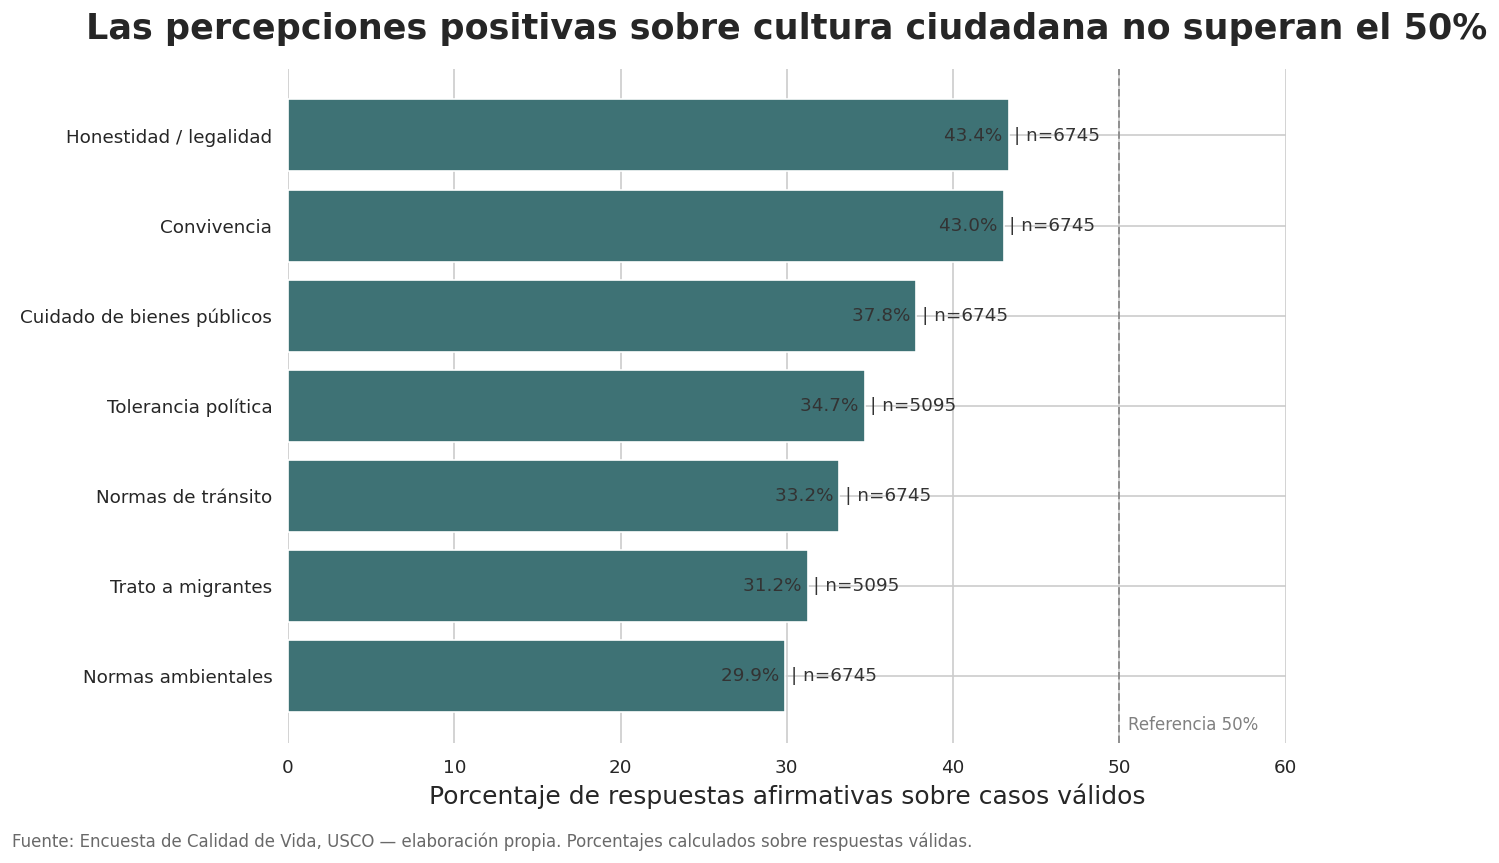


Resumen de datos faltantes:



,Variable,Total base,Respuestas válidas,NA / Sin dato,% NA
0,Honestidad / legalidad,6745,6745,0,0.00
1,Convivencia,6745,6745,0,0.00
2,Cuidado de bienes públicos,6745,6745,0,0.00
3,Normas de tránsito,6745,6745,0,0.00
4,Normas ambientales,6745,6745,0,0.00
5,Trato a migrantes,6745,5095,1650,24.46
6,Tolerancia política,6745,5095,1650,24.46



INTERPRETACIÓN GENERAL:

En términos generales, ninguna de las variables analizadas supera el 50% de respuestas afirmativas sobre casos válidos, lo que sugiere percepciones moderadas o bajas frente a distintas dimensiones de cultura ciudadana.

Las mayores proporciones de respuestas positivas se observan en honestidad/legalidad y convivencia, mientras que los niveles más bajos se presentan en normas ambientales y normas de tránsito.

Asimismo, las variables relacionadas con trato a migrantes y tolerancia política presentan una reducción en el denominador válido (n=5095), debido a la existencia de 1650 registros NA/sin dato (24.46% de la base total).

Por esta razón, los porcentajes de estas variables fueron calculados únicamente sobre respuestas válidas, siguiendo criterios metodológicos de transparencia y comparabilidad.


In [84]:
# ============================================================
# PARTE 1.
# RANKING GENERAL DE CULTURA CIUDADANA
# ============================================================

# ------------------------------------------------------------
# Construcción de ranking general
# ------------------------------------------------------------

ranking_general = []

for var in vars_cultura:

    n_validos = df_cultura[var].notna().sum()
    n_si = (df_cultura[var] == 1).sum()

    porcentaje_si = (n_si / n_validos) * 100

    ranking_general.append({
        "variable": var,
        "interpretacion_conceptual": diccionario_conceptual[var],
        "n_validos": n_validos,
        "n_si": n_si,
        "porcentaje_si": porcentaje_si
    })

ranking_general = pd.DataFrame(ranking_general)

ranking_general = ranking_general.sort_values(
    by="porcentaje_si",
    ascending=False
).reset_index(drop=True)

print("\nRanking general de cumplimiento/percepción positiva:\n")

display(
    ranking_general.round(2)
)

# ------------------------------------------------------------
# Etiquetas bonitas para visualización
# ------------------------------------------------------------

etiquetas_ranking = {
    "honestidad": "Honestidad / legalidad",
    "convivencia": "Convivencia",
    "bienes": "Cuidado de bienes públicos",
    "tránsito": "Normas de tránsito",
    "ambiental": "Normas ambientales",
    "migrantes": "Trato a migrantes",
    "pensamiento": "Tolerancia política"
}

ranking_general["etiqueta"] = (
    ranking_general["variable"]
    .map(etiquetas_ranking)
)

# ------------------------------------------------------------
# Orden para gráfico
# ------------------------------------------------------------

ranking_general = ranking_general.sort_values(
    by="porcentaje_si",
    ascending=True
)

# ============================================================
# GRÁFICO 1.
# Ranking general cultura ciudadana
# ============================================================

plt.figure(figsize=(11, 7))

bars = plt.barh(
    ranking_general["etiqueta"],
    ranking_general["porcentaje_si"],
    color="#3E7275"
)

# Línea de referencia 50%
plt.axvline(
    50,
    linestyle="--",
    linewidth=1.2,
    color="gray",
    alpha=0.8
)

# Etiquetas sobre barras
for bar, pct, n in zip(
    bars,
    ranking_general["porcentaje_si"],
    ranking_general["n_validos"]
):

    plt.text(
        pct + 0.8,
        bar.get_y() + bar.get_height()/2,
        f"{pct:.1f}%  | n={n}",
        ha="center",
        va="center",
        fontsize=11,
        color="#333333"
    )

# Títulos
plt.title(
    "Las percepciones positivas sobre cultura ciudadana no superan el 50%",
    fontsize=21,
    weight="bold",
    pad=18
)


# Ejes
plt.xlabel(
    "Porcentaje de respuestas afirmativas sobre casos válidos",
    fontsize=15
)

plt.xlim(0, 60)

# Texto línea 50%
plt.text(
    50.5,
    -0.6,
    "Referencia 50%",
    fontsize=10,
    color="gray"
)

# Fuente
plt.figtext(
    0.01,
    -0.02,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia. "
    "Porcentajes calculados sobre respuestas válidas.",
    ha="left",
    fontsize=10,
    color="dimgray"
)

sns.despine(left=True, bottom=True)

plt.tight_layout()

# Guardar
plt.savefig(
    carpeta_graficos / "parte1_ranking_general_cultura_ciudadana.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# TABLA RESUMEN DE DATOS FALTANTES (NA)
# ============================================================

tabla_na = []

for var in vars_cultura:

    total = len(df_cultura)

    n_na = df_cultura[var].isna().sum()

    n_validos = total - n_na

    porcentaje_na = (n_na / total) * 100

    tabla_na.append({
        "Variable": etiquetas_ranking[var],
        "Total base": total,
        "Respuestas válidas": n_validos,
        "NA / Sin dato": n_na,
        "% NA": round(porcentaje_na, 2)
    })

tabla_na = pd.DataFrame(tabla_na)

print("\nResumen de datos faltantes:\n")

display(tabla_na)

# ============================================================
# TEXTO NARRATIVO AUTOMÁTICO
# ============================================================

print("\nINTERPRETACIÓN GENERAL:\n")

print(
    "En términos generales, ninguna de las variables analizadas "
    "supera el 50% de respuestas afirmativas sobre casos válidos, "
    "lo que sugiere percepciones moderadas o bajas frente a distintas "
    "dimensiones de cultura ciudadana."
)

print(
    "\nLas mayores proporciones de respuestas positivas se observan en "
    "honestidad/legalidad y convivencia, mientras que los niveles más bajos "
    "se presentan en normas ambientales y normas de tránsito."
)

print(
    "\nAsimismo, las variables relacionadas con trato a migrantes y "
    "tolerancia política presentan una reducción en el denominador válido "
    "(n=5095), debido a la existencia de 1650 registros NA/sin dato "
    "(24.46% de la base total)."
)

print(
    "\nPor esta razón, los porcentajes de estas variables fueron calculados "
    "únicamente sobre respuestas válidas, siguiendo criterios metodológicos "
    "de transparencia y comparabilidad."
)

In [45]:
# ============================================================
#  ANÁLISIS SEGÚN CHI-CUADRADO
# Solo se profundizan cruces estadísticamente significativos
# ============================================================

import matplotlib.ticker as mtick

# ------------------------------------------------------------
# 1. Etiquetas y estilo visual
# ------------------------------------------------------------

etiquetas_vars = {
    "honestidad": "Honestidad / legalidad",
    "convivencia": "Convivencia",
    "bienes": "Cuidado de bienes públicos",
    "tránsito": "Normas de tránsito",
    "ambiental": "Normas ambientales",
    "migrantes": "Trato a migrantes",
    "pensamiento": "Tolerancia política"
}

orden_vars = [
    "honestidad",
    "convivencia",
    "bienes",
    "tránsito",
    "ambiental",
    "migrantes",
    "pensamiento"
]

color_si = "#1F4E79"
color_no = "#AEB7C6"
color_titulo = "#1F2937"
color_subtitulo = "#5F6B7A"

sns.set_theme(style="whitegrid", font="DejaVu Sans")

plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 120
})


In [46]:
# ------------------------------------------------------------
# 2. Tabla resumen de chi-cuadrado como filtro
# ------------------------------------------------------------

chi2_relevancia = resultados_chi2.copy()

chi2_relevancia["Variable"] = chi2_relevancia["variable"].map(etiquetas_vars)

chi2_relevancia["Cruce"] = chi2_relevancia["cruce"].map({
    "municipio_2025": "Municipio, solo 2025",
    "sexo_base_total": "Sexo, base total",
    "nivel_socioeconomico_base_total": "Nivel socioeconómico, base total"
})

chi2_relevancia["Significativo"] = np.where(
    chi2_relevancia["p_valor"] < 0.05,
    "Sí",
    "No"
)

tabla_chi2_relevancia = chi2_relevancia[[
    "Cruce",
    "Variable",
    "p_valor",
    "n_observaciones_validas",
    "Significativo"
]].rename(columns={
    "p_valor": "p-valor",
    "n_observaciones_validas": "n válido"
})

display(
    tabla_chi2_relevancia.style
    .hide(axis="index")
    .format({"p-valor": "{:.4f}"})
    .set_properties(**{
        "text-align": "center",
        "font-size": "10.5pt"
    })
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("background-color", "#1F4E79"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        }
    ])
)

tabla_chi2_relevancia.to_excel(
    carpeta_tablas / "parte3_chi2_filtro_relevancia.xlsx",
    index=False
)




Cruce,Variable,p-valor,n válido,Significativo
"Municipio, solo 2025",Honestidad / legalidad,0.0000,2236,Sí
"Municipio, solo 2025",Convivencia,0.0000,2236,Sí
"Municipio, solo 2025",Cuidado de bienes públicos,0.0598,2236,No
"Municipio, solo 2025",Normas de tránsito,0.0000,2236,Sí
"Municipio, solo 2025",Normas ambientales,0.0144,2236,Sí
"Municipio, solo 2025",Trato a migrantes,0.0000,2236,Sí
"Municipio, solo 2025",Tolerancia política,0.0000,2236,Sí
"Sexo, base total",Honestidad / legalidad,0.1024,6745,No
"Sexo, base total",Convivencia,0.0451,6745,Sí
"Sexo, base total",Cuidado de bienes públicos,0.3627,6745,No


In [47]:
# ------------------------------------------------------------
# 3. Identificar variables significativas por cruce
# ------------------------------------------------------------

vars_sig_municipio = (
    chi2_relevancia[
        (chi2_relevancia["cruce"] == "municipio_2025") &
        (chi2_relevancia["p_valor"] < 0.05)
    ]["variable"]
    .tolist()
)

vars_sig_sexo = (
    chi2_relevancia[
        (chi2_relevancia["cruce"] == "sexo_base_total") &
        (chi2_relevancia["p_valor"] < 0.05)
    ]["variable"]
    .tolist()
)

vars_sig_nivels = (
    chi2_relevancia[
        (chi2_relevancia["cruce"] == "nivel_socioeconomico_base_total") &
        (chi2_relevancia["p_valor"] < 0.05)
    ]["variable"]
    .tolist()
)

print("Variables significativas por municipio:", vars_sig_municipio)
print("Variables significativas por sexo:", vars_sig_sexo)
print("Variables significativas por nivel socioeconómico:", vars_sig_nivels)




Variables significativas por municipio: ['honestidad', 'convivencia', 'tránsito', 'ambiental', 'migrantes', 'pensamiento']
Variables significativas por sexo: ['convivencia', 'tránsito', 'ambiental', 'migrantes', 'pensamiento']
Variables significativas por nivel socioeconómico: ['honestidad', 'convivencia', 'bienes', 'tránsito', 'ambiental', 'migrantes', 'pensamiento']


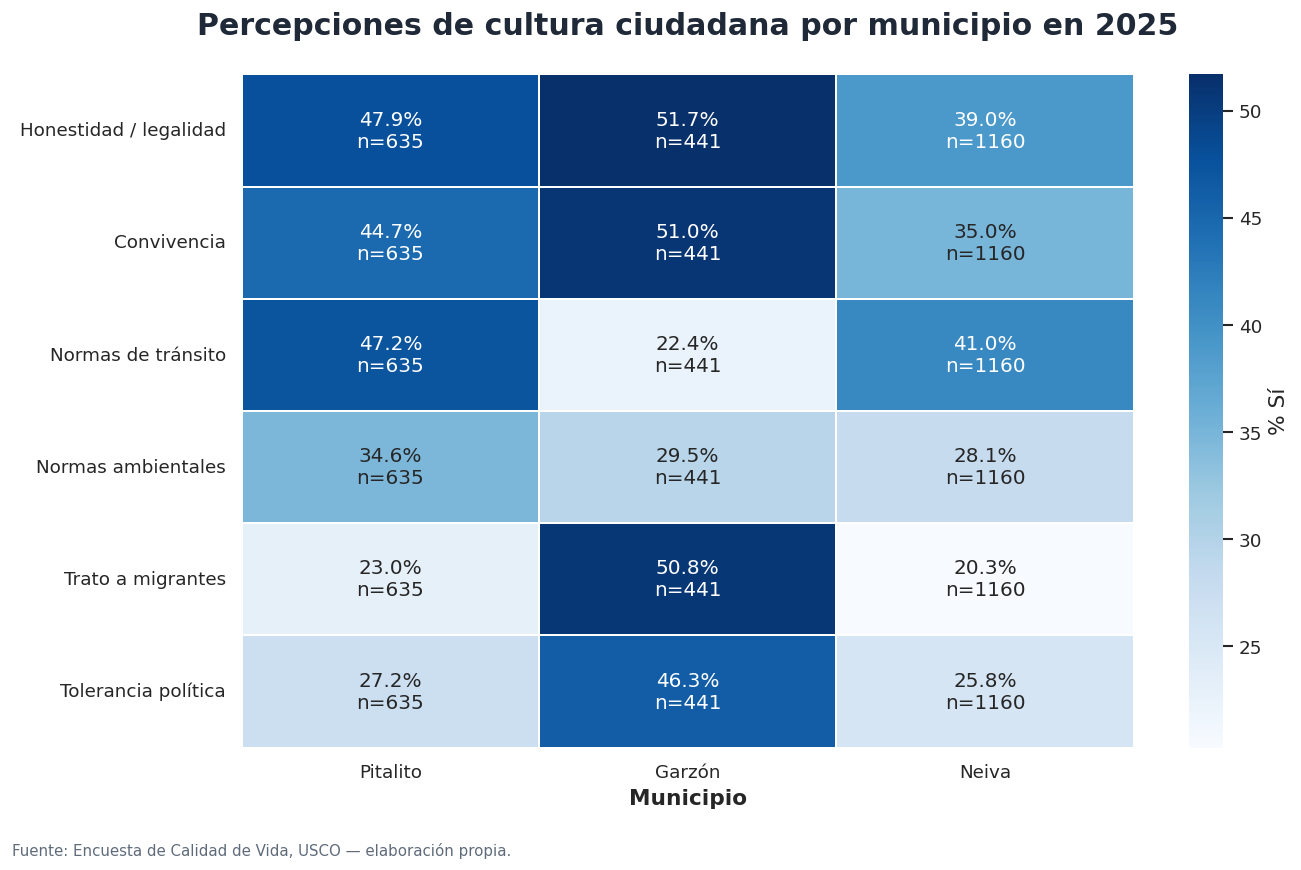

In [81]:
# ============================================================
# GRÁFICO 3A. MUNICIPIO 2025
# Solo variables significativas según chi-cuadrado
# ============================================================

mun_sig = municipio_2025[municipio_2025["variable"].isin(vars_sig_municipio)].copy()
mun_sig["Variable"] = mun_sig["variable"].map(etiquetas_vars)

# Orden visual
mun_sig["Variable"] = pd.Categorical(
    mun_sig["Variable"],
    categories=[etiquetas_vars[v] for v in orden_vars if v in vars_sig_municipio],
    ordered=True
)

tabla_mun_sig = mun_sig.pivot_table(
    index="Variable",
    columns="municipio_etq",
    values="porcentaje_si",
    observed=False
)

tabla_mun_n = mun_sig.pivot_table(
    index="Variable",
    columns="municipio_etq",
    values="n_validos",
    observed=False
)

# Orden de columnas
tabla_mun_sig = tabla_mun_sig[["Pitalito", "Garzón", "Neiva"]]
tabla_mun_n = tabla_mun_n[["Pitalito", "Garzón", "Neiva"]]

annot_mun = tabla_mun_sig.copy().astype(str)

for fila in tabla_mun_sig.index:
    for col in tabla_mun_sig.columns:
        val = tabla_mun_sig.loc[fila, col]
        n = tabla_mun_n.loc[fila, col]
        annot_mun.loc[fila, col] = f"{val:.1f}%\nn={int(n)}"

plt.figure(figsize=(11.5, 7))

ax = sns.heatmap(
    tabla_mun_sig,
    annot=annot_mun,
    fmt="",
    cmap="Blues",
    linewidths=1.2,
    linecolor="white",
    cbar_kws={"label": "% Sí"}
)

ax.set_title(
    "Percepciones de cultura ciudadana por municipio en 2025",
    fontsize=18,
    weight="bold",
    color=color_titulo,
    pad=24
)


ax.set_xlabel("Municipio", fontsize=13, weight="bold")
ax.set_ylabel("")

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia. ",
    ha="left",
    fontsize=9,
    color=color_subtitulo
)

plt.tight_layout()
plt.savefig(
    carpeta_graficos / "parte3_01_municipio_2025_significativas.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()




In [ ]:
# ============================================================
#  NIVEL SOCIOECONÓMICO
# Barras apiladas al 100%, todas significativas
# ============================================================

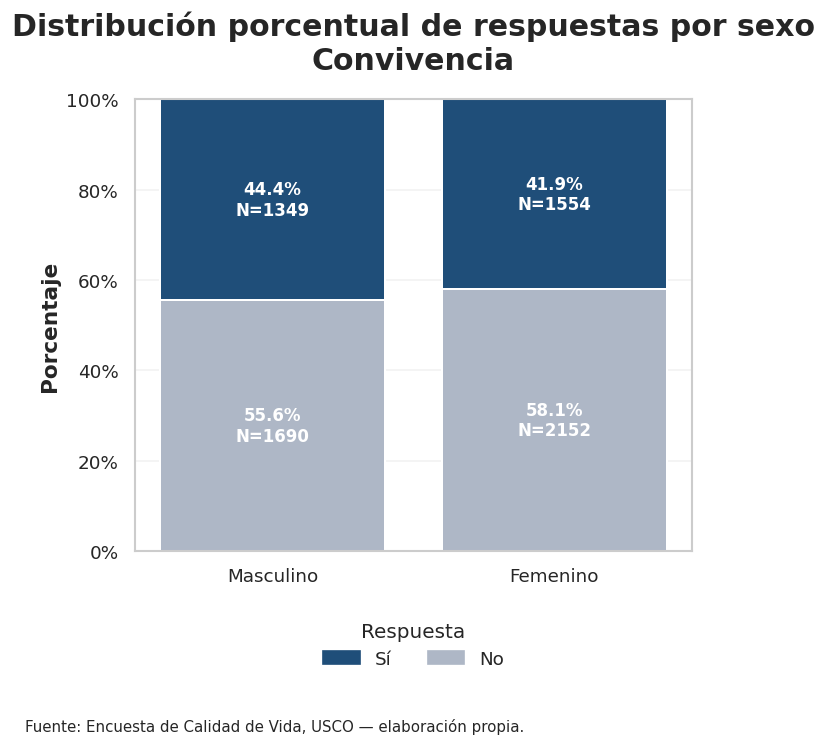

In [75]:
# ============================================================
# VARIABLE 1. CONVIVENCIA
# ============================================================

var = "convivencia"
nombre_var = "Convivencia"

sub = df_sexo_long[df_sexo_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(5.8, 6))

orden_sexo = ["Masculino", "Femenino"]
bottom = np.zeros(len(orden_sexo))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for sexo in orden_sexo:

        fila = sub[
            (sub["sexo_etq"] == sexo) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_sexo,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por sexo\nConvivencia",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    carpeta_graficos / "sexo_convivencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

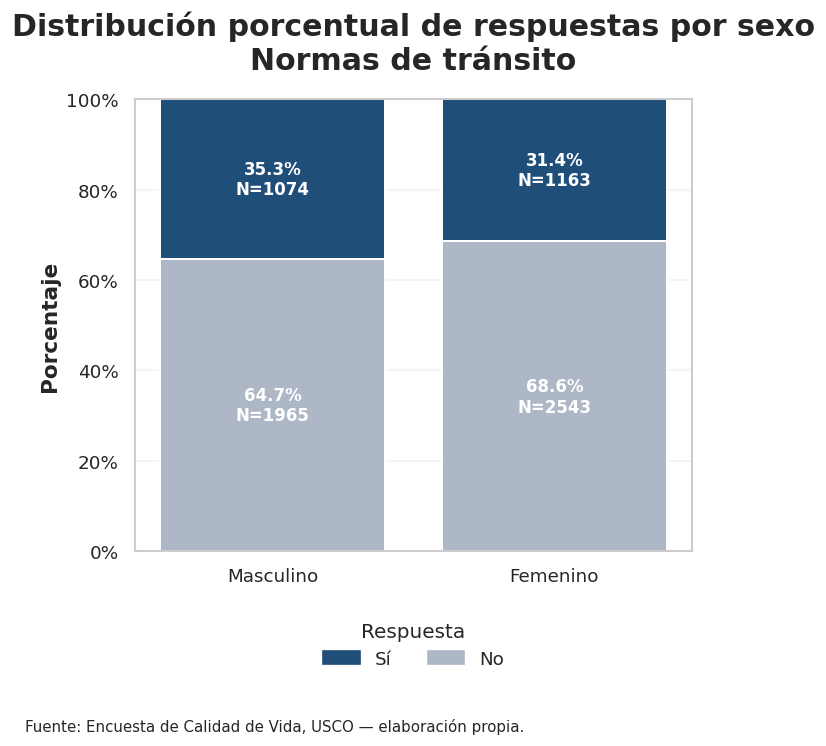

In [76]:
# ============================================================
# VARIABLE 2. NORMAS DE TRÁNSITO
# ============================================================

var = "tránsito"
nombre_var = "Normas de tránsito"

sub = df_sexo_long[df_sexo_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(5.8, 6))

orden_sexo = ["Masculino", "Femenino"]
bottom = np.zeros(len(orden_sexo))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for sexo in orden_sexo:

        fila = sub[
            (sub["sexo_etq"] == sexo) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_sexo,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por sexo\nNormas de tránsito",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    carpeta_graficos / "sexo_transito.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

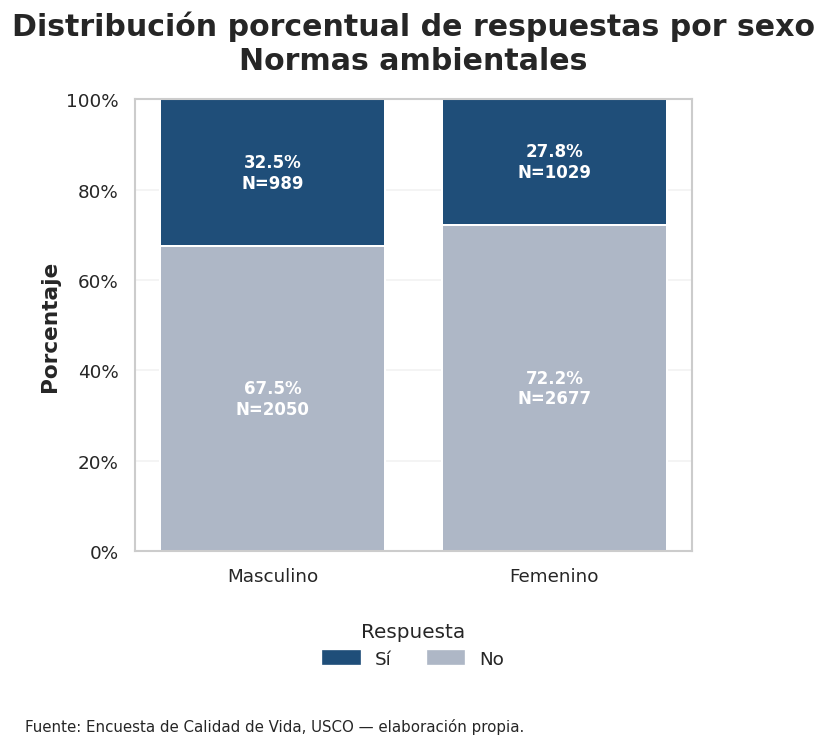

In [77]:
# ============================================================
# VARIABLE 3. NORMAS AMBIENTALES
# ============================================================

var = "ambiental"
nombre_var = "Normas ambientales"

sub = df_sexo_long[df_sexo_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(5.8, 6))

orden_sexo = ["Masculino", "Femenino"]
bottom = np.zeros(len(orden_sexo))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for sexo in orden_sexo:

        fila = sub[
            (sub["sexo_etq"] == sexo) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_sexo,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por sexo\nNormas ambientales",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    carpeta_graficos / "sexo_ambiental.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

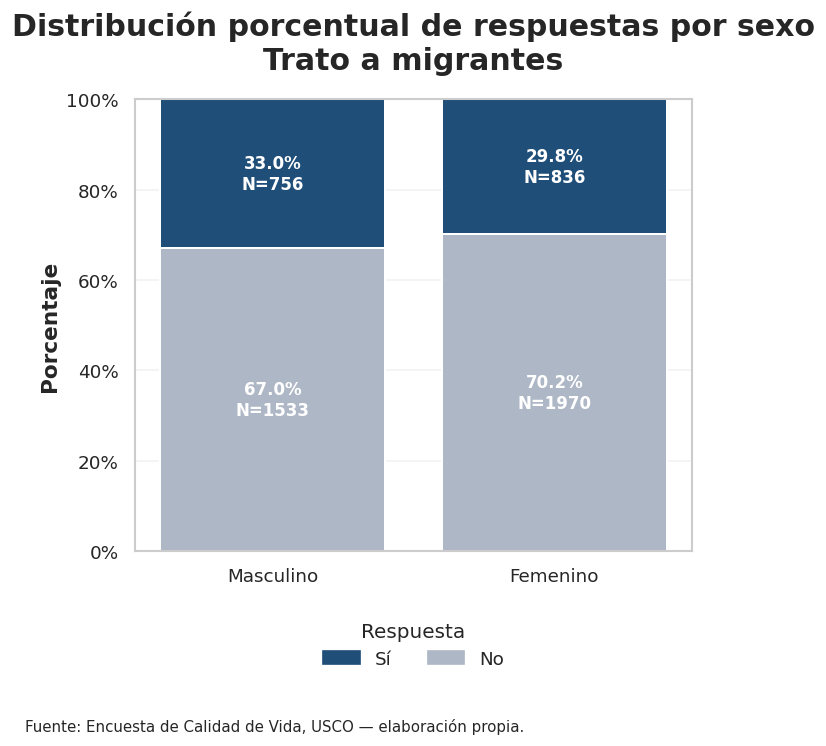

In [78]:
# ============================================================
# VARIABLE 4. TRATO A MIGRANTES
# ============================================================

var = "migrantes"
nombre_var = "Trato a migrantes"

sub = df_sexo_long[df_sexo_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(5.8, 6))

orden_sexo = ["Masculino", "Femenino"]
bottom = np.zeros(len(orden_sexo))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for sexo in orden_sexo:

        fila = sub[
            (sub["sexo_etq"] == sexo) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_sexo,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por sexo\nTrato a migrantes",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    carpeta_graficos / "sexo_migrantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

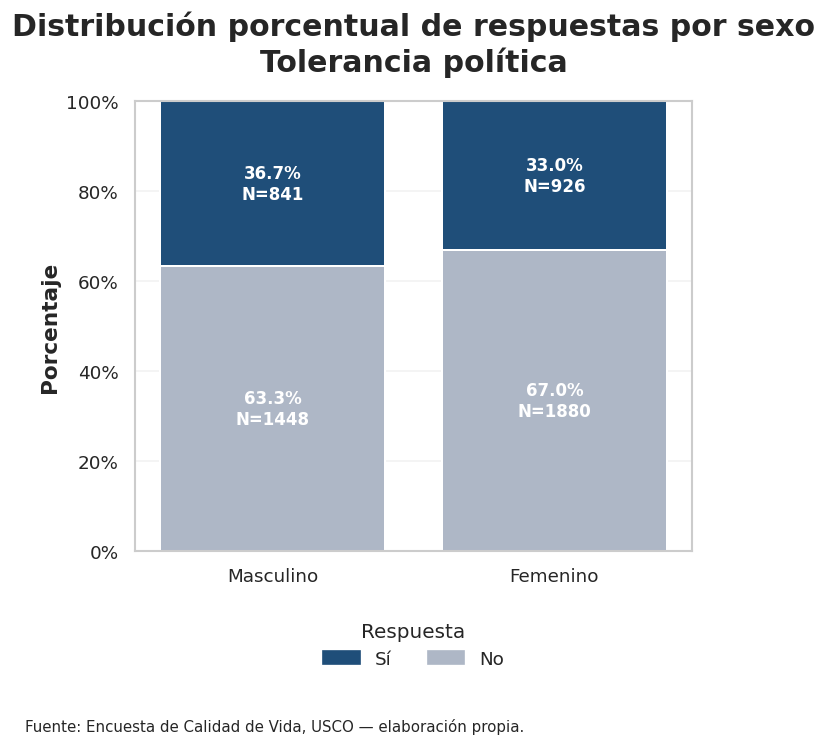

In [79]:
# ============================================================
# VARIABLE 5. TOLERANCIA POLÍTICA
# ============================================================

var = "pensamiento"
nombre_var = "Tolerancia política"

sub = df_sexo_long[df_sexo_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(5.8, 6))

orden_sexo = ["Masculino", "Femenino"]
bottom = np.zeros(len(orden_sexo))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for sexo in orden_sexo:

        fila = sub[
            (sub["sexo_etq"] == sexo) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_sexo,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por sexo\nTolerancia política",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    carpeta_graficos / "sexo_pensamiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [74]:
# ============================================================
#  NIVEL SOCIOECONÓMICO
# Barras apiladas al 100%, todas significativas
# ============================================================

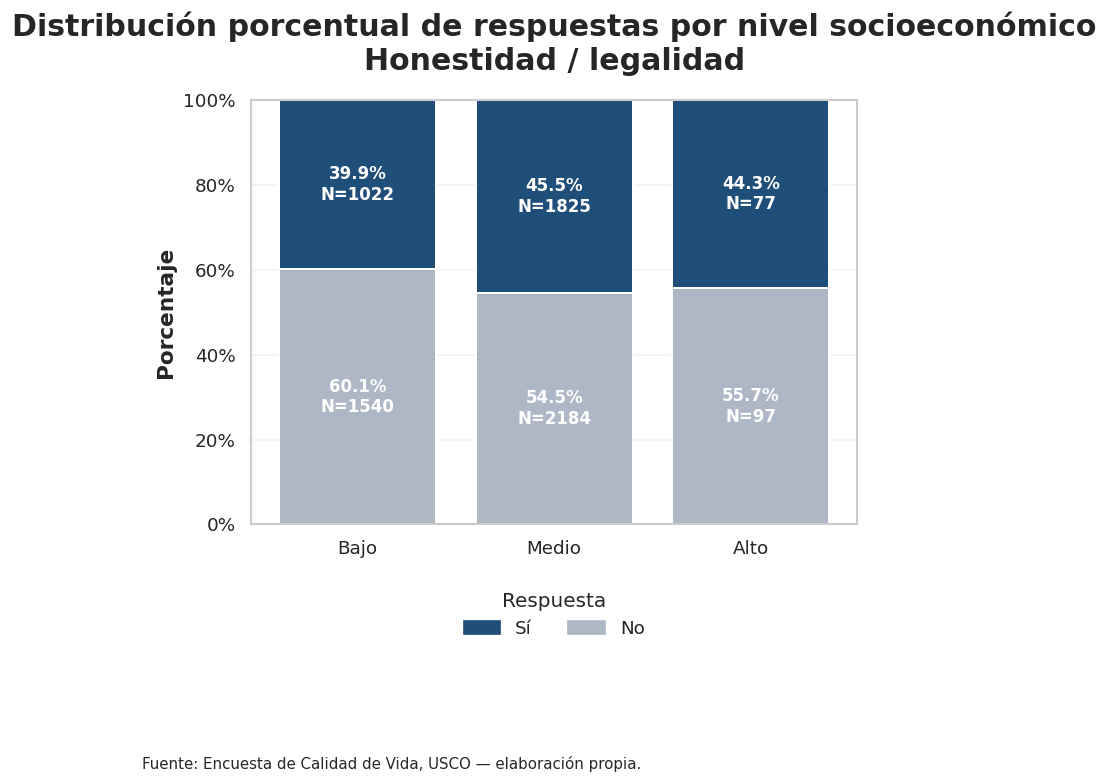

In [66]:
# ============================================================
# VARIABLE 1. HONESTIDAD / LEGALIDAD
# ============================================================

var = "honestidad"
nombre_var = "Honestidad / legalidad"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nHonestidad / legalidad",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_honestidad.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

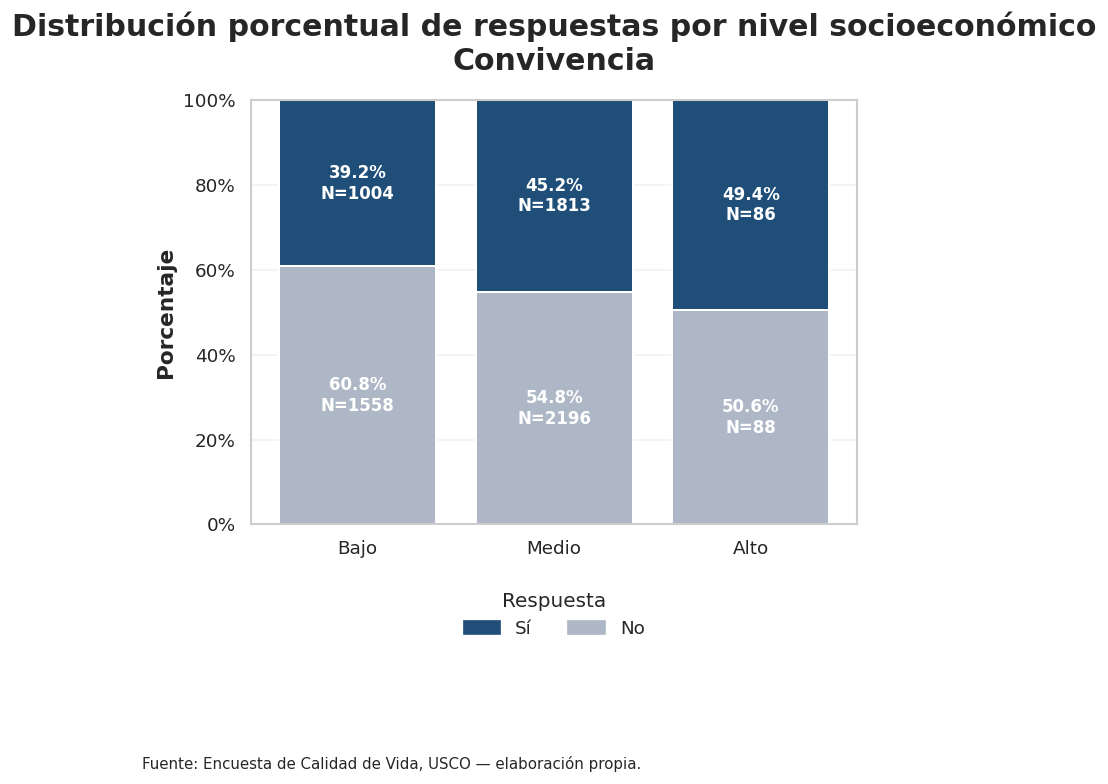

In [67]:
# ============================================================
# VARIABLE 2. CONVIVENCIA
# ============================================================

var = "convivencia"
nombre_var = "Convivencia"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nConvivencia",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_convivencia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

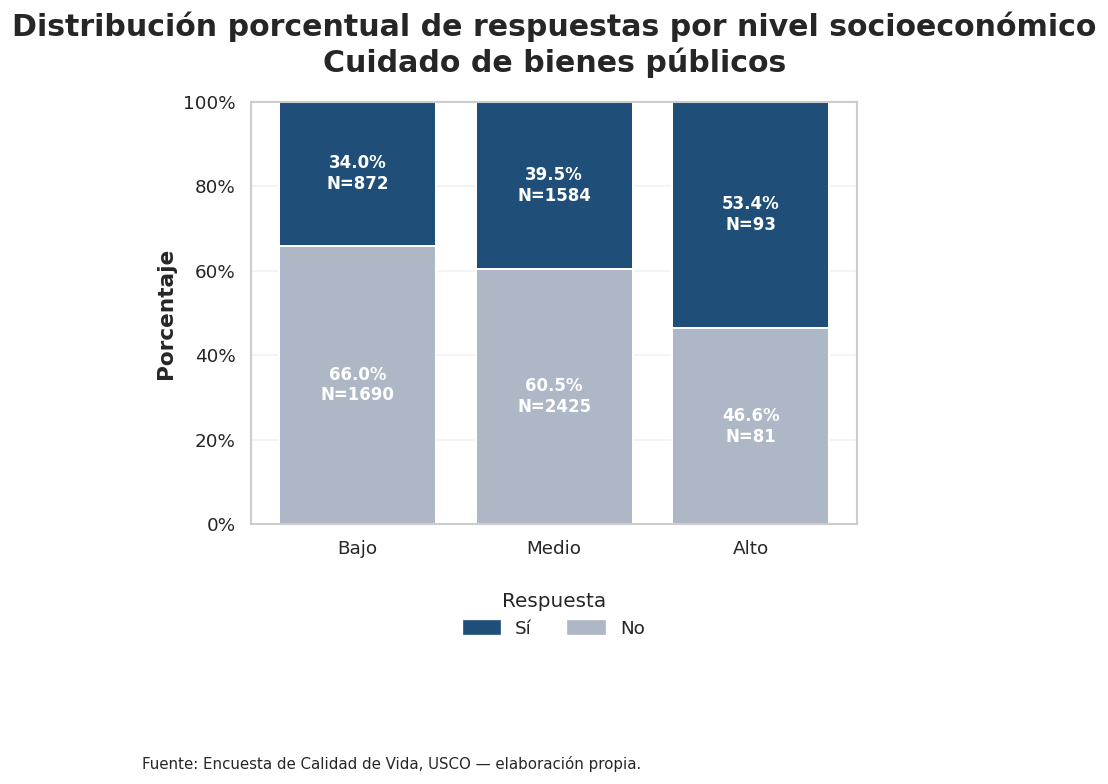

In [68]:
# ============================================================
# VARIABLE 3. CUIDADO DE BIENES PÚBLICOS
# ============================================================

var = "bienes"
nombre_var = "Cuidado de bienes públicos"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nCuidado de bienes públicos",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_bienes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

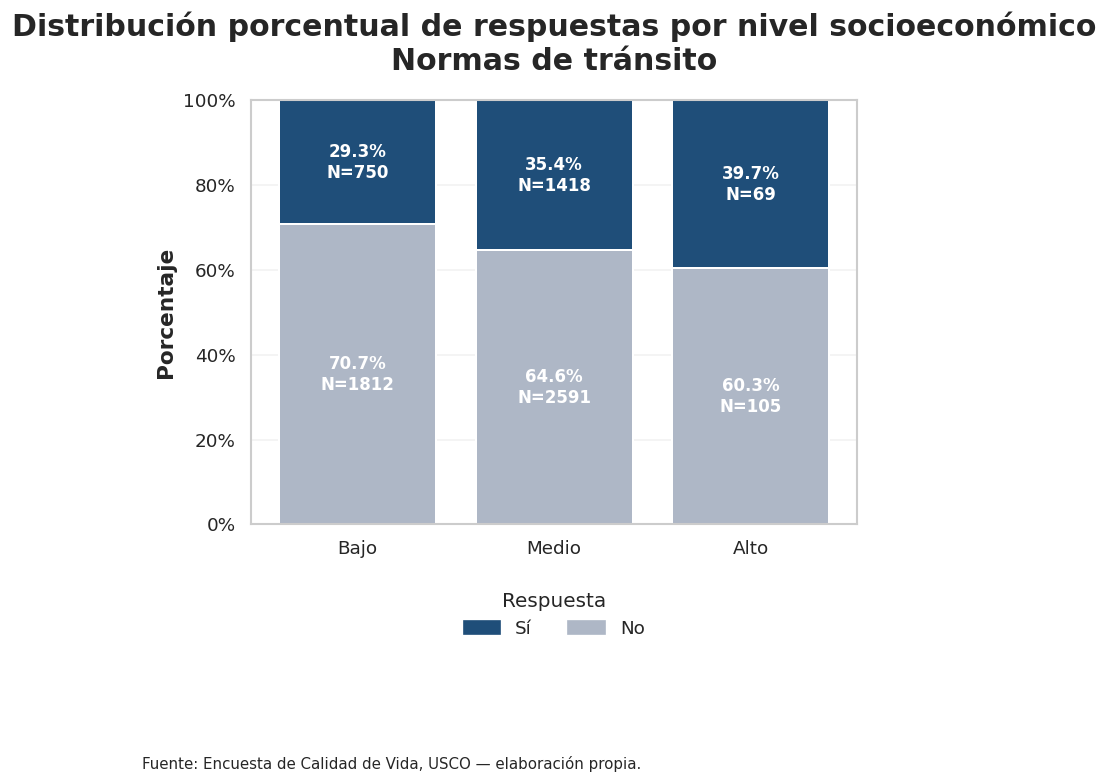

In [69]:
# ============================================================
# VARIABLE 4. NORMAS DE TRÁNSITO
# ============================================================

var = "tránsito"
nombre_var = "Normas de tránsito"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nNormas de tránsito",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_transito.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

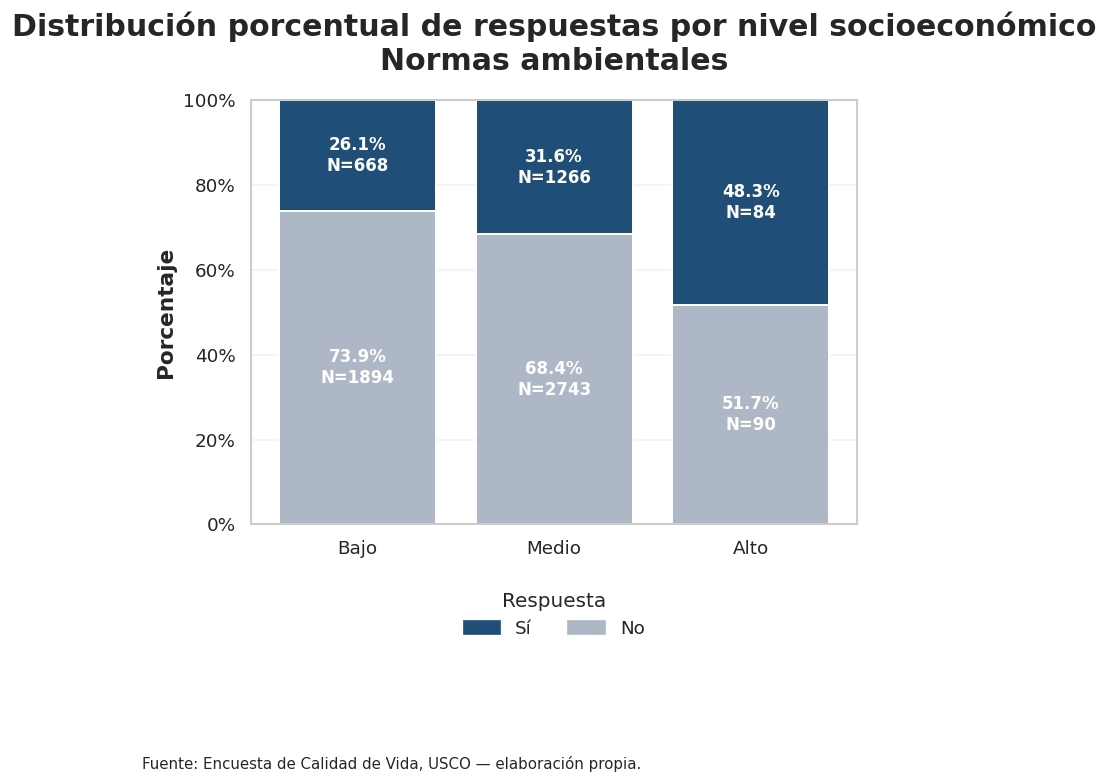

In [70]:
# ============================================================
# VARIABLE 5. NORMAS AMBIENTALES
# ============================================================

var = "ambiental"
nombre_var = "Normas ambientales"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nNormas ambientales",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_ambiental.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

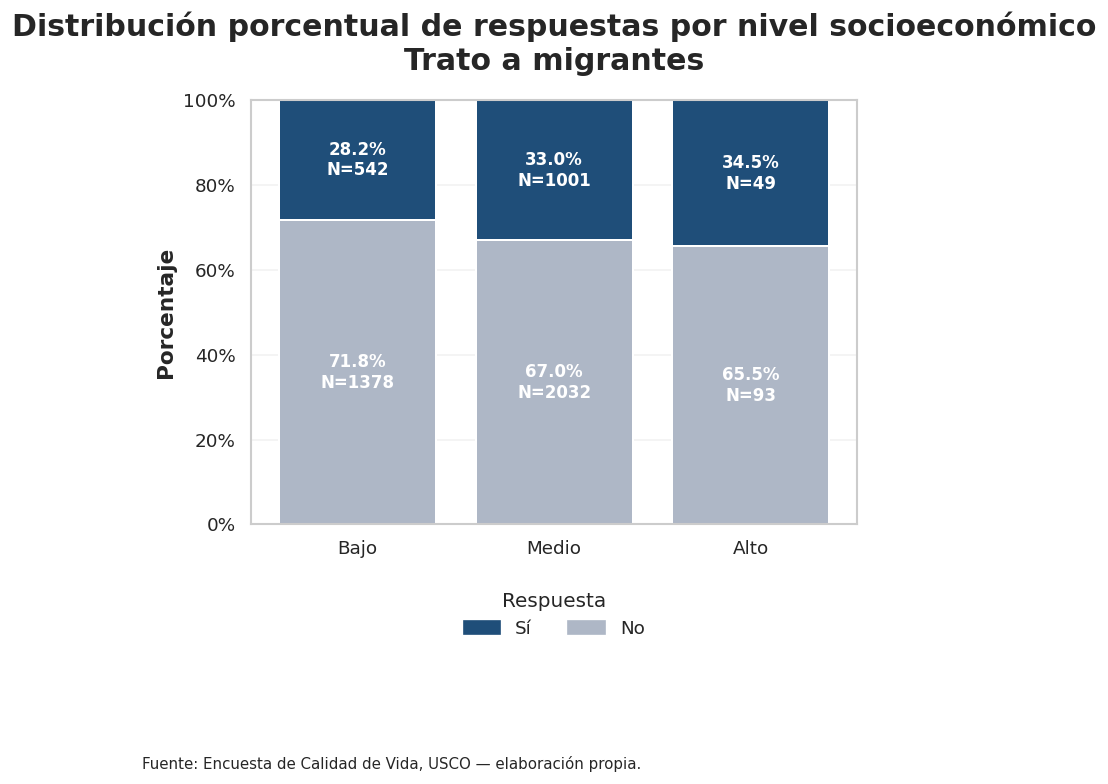

In [71]:
# ============================================================
# VARIABLE 6. TRATO A MIGRANTES
# ============================================================

var = "migrantes"
nombre_var = "Trato a migrantes"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nTrato a migrantes",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_migrantes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

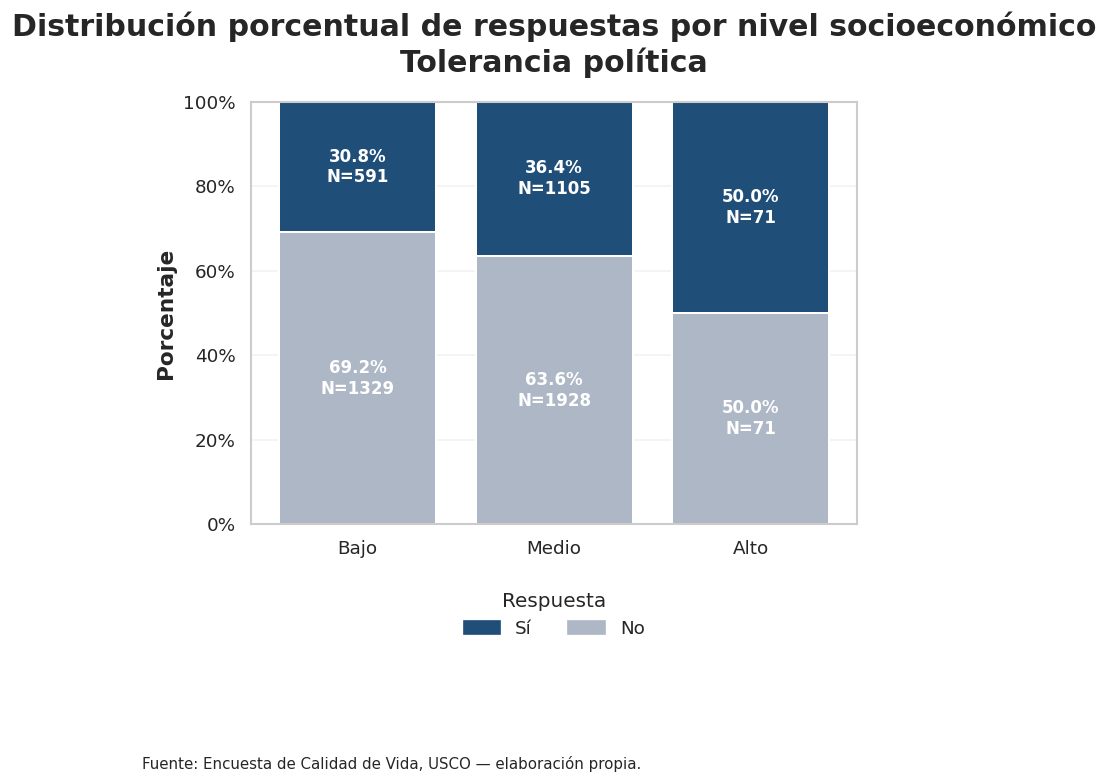

In [72]:
# ============================================================
# VARIABLE 7. TOLERANCIA POLÍTICA
# ============================================================

var = "pensamiento"
nombre_var = "Tolerancia política"

sub = df_nivels_long[df_nivels_long["variable"] == var].copy()

fig, ax = plt.subplots(figsize=(6.2, 6.3))

orden_nivels = ["Bajo", "Medio", "Alto"]
bottom = np.zeros(len(orden_nivels))

for respuesta, color in [("No", color_no), ("Sí", color_si)]:

    vals = []
    ns = []

    for nivel in orden_nivels:

        fila = sub[
            (sub["nivels_etq"] == nivel) &
            (sub["respuesta"] == respuesta)
        ]

        vals.append(float(fila["porcentaje"].iloc[0]))
        ns.append(int(fila["n"].iloc[0]))

    bars = ax.bar(
        orden_nivels,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=1.2
    )

    for i, bar in enumerate(bars):

        ax.text(
            bar.get_x() + bar.get_width()/2,
            bottom[i] + vals[i]/2,
            f"{vals[i]:.1f}%\nN={ns[i]}",
            ha="center",
            va="center",
            fontsize=10,
            color="white",
            weight="bold"
        )

    bottom += np.array(vals)

ax.set_title(
    "Distribución porcentual de respuestas por nivel socioeconómico\nTolerancia política",
    fontsize=18,
    weight="bold",
    pad=18
)

ax.set_ylabel("Porcentaje", fontsize=13, weight="bold")
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax.grid(axis="y", alpha=0.25)

handles = [
    plt.Rectangle((0,0),1,1,color=color_si),
    plt.Rectangle((0,0),1,1,color=color_no)
]

ax.legend(
    handles,
    ["Sí", "No"],
    title="Respuesta",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

plt.figtext(
    0.01,
    -0.03,
    "Fuente: Encuesta de Calidad de Vida, USCO — elaboración propia.",
    fontsize=9
)

plt.tight_layout(rect=[0, 0.08, 1, 1])

plt.savefig(
    carpeta_graficos / "nivels_pensamiento.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()